In [3]:
# Box model written by Neosha after Brinkerhoff et al. (2016)
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

## Model code

In [4]:


def rhs(t, state, Q_in_func, k_hat, gamma, psi, r_hat, chi, pi, alpha, beta, n=3):

    A_hat, P_hat = state

    # Enforce physical bounds
    A_hat = max(A_hat, 0.0)
    Phat_upper_bound = 10 # by default, 1.0: when P_hat = 1, overburden, 0 = atmospheric pressure
    P_hat = np.clip(P_hat, 0.0, Phat_upper_bound)

    eps = 1e-6
    effective_pressure = max(Phat_upper_bound - P_hat, eps)  # prevents singularity
    
    # Equation 7
    sliding_opening = k_hat/((1-P_hat)**gamma)
    melting_opening = psi * r_hat * A_hat**alpha * P_hat**beta
    creep_closure = A_hat * (1 - P_hat)**n

    dA_dt = sliding_opening + melting_opening - creep_closure

    # Equation 8
    dP_dt = chi*(Q_in_func(t) - r_hat * A_hat**alpha * P_hat**(beta-1) - pi*dA_dt)

    return dA_dt, dP_dt

In [5]:
# Initial values from MCMC
'''
A0_hat = 0.9 # Initial cavity size (defined with MCMC)
P0_hat = 0.2 # Initial pressure (defined MCMC)
k_hat = 0.44 # Basal traction coefficient
r_hat = 0.02 # linear flux coefficient


Pi = 0.09 # From Bartholomaus et al. 
Psi = 0.018 # From Bartholomaus et al. 
Chi = 3.41 # Englacial storage coefficient from Bartholomaus
gamma = 0.22 # nonlinear dependence of sliding speed on effective pressure
alpha = 5/4
beta = 3/2
'''


A0_hat = 0.9
P0_hat = 0.1
k_hat  = 0.44 # velocity parameter
r_hat  = 0.02
Pi     = 0.09 #0.44   # was 0.09
Psi    =  0.018 #0.61   # was 0.018
Chi    = 0.5   # 3.41 # was 0.11  
gamma  =  0.4 # 0.4    # was 0.22 #  <--- model stability is sensitive to this! 
alpha  = 5/4   # was 5/4 # closure and opening rates?
beta   = 3/2   # was 3/2

In [ ]:
def solve(t_span, t_eval, Q_in_func):
    params = dict(
        Q_in_func=Q_in_func,
        k_hat=k_hat, gamma=gamma, psi=Psi, r_hat=r_hat,
        chi=Chi, pi=Pi, alpha=alpha, beta=beta, n=3
    )
    solution = solve_ivp(
        fun = lambda t, y: rhs(t, y, **params),  # y = state
        t_span = t_span,
        t_eval = t_eval,
        y0 = [A0_hat, P0_hat],
        method = "RK45", # Runge Kutta
        max_step=0.05,
        rtol=1e-6,
        atol=1e-8,
    )

    # Calculate values
    A_hat = solution.y[0]
    P_hat = np.clip(solution.y[1], 0.0, 1.0)
    Q_out = r_hat * A_hat**alpha * P_hat**(beta-1)
    cavitation = k_hat/(1-P_hat)**gamma
    #print(solution.status)

    
    return solution.t, A_hat, P_hat, Q_out, cavitation

## Generate flood with different shapes of outburst impulse

In [48]:
def make_synthetic_Q_in(t_flood, flood_magnitude, flood_width, floodtype):
    """
    t_flood (int): day on which the flood occurs
    flood_magnitude (float): maximum magnitude of the rising part of the flood
    flood_width (float): duration of flood
    floodtype (str): "norm" = flood takes sinusoidal shape, "long" = long leadup flood
    """
    seasonal = 0.5 # Background value
    def Q_in_normal(t):
        #seasonal = 0.5 + 0.5 * (t / 50.0)           # slow ramp up
        diurnal  = 0.4 * np.sin(2 * np.pi * t)       # ~1 nondim day period
        flood    = flood_magnitude * np.exp(
                       -((t - t_flood) ** 2) / (2 * flood_width ** 2)) # normal curve centered about mean t_flood

        #total_Q = seasonal+diurnal+flood
        total_Q = seasonal + flood
        return max(total_Q, 0.0)

    def Q_in_longleadup(t):
         # Find the flood definition from matlab SHAKTI and put in here.
        falling_width = flood_width/10

        a = flood_magnitude/flood_width

        if t > t_flood and t <= t_flood + flood_width:
            Q = seasonal + a*(t-t_flood)
        elif t > t_flood + flood_width and t <= t_flood + flood_width + falling_width:
            b = -flood_magnitude/falling_width
            Q = seasonal + b*(t-(t_flood + flood_width)) + flood_magnitude
        else:
            Q = seasonal
         
        return max(Q, 0.0)

    if floodtype=="norm":
        return Q_in_normal
    if floodtype=="long":
        return Q_in_longleadup
    else:
        print("invalid flood type: returning normal")
        return Q_in_normal
    #return Q_in_longleadup

In [ ]:
t_start, t_end = 0.0, 200.00
t_eval = np.linspace(t_start, t_end, 500)


# DEFINE FLOOD PARAMS!!! 

'''
# FOR LONG LEADUP:
t_flood=100
flood_magnitude=3.0
flood_width=50
'''

# FOR NORMAL CURVE:
t_flood = 100
flood_magnitude = 0.5
flood_width = 1.0

Q_in_func = make_synthetic_Q_in(t_flood, flood_magnitude, flood_width, "norm")

times, A_hat, P_hat, Q_out, cavitation = solve(
    t_span=(t_start, t_end),
    t_eval = t_eval,
    Q_in_func=Q_in_func
)

In [51]:
# Calculate pressure deficit

t_pre = t_flood - 1
t_post = t_flood + int(flood_width) + 8
P_pre = P_hat[t_pre]
P_post = P_hat[t_post]

P_deficit = P_pre/P_post
P_deficit

np.float64(0.9519237019528924)

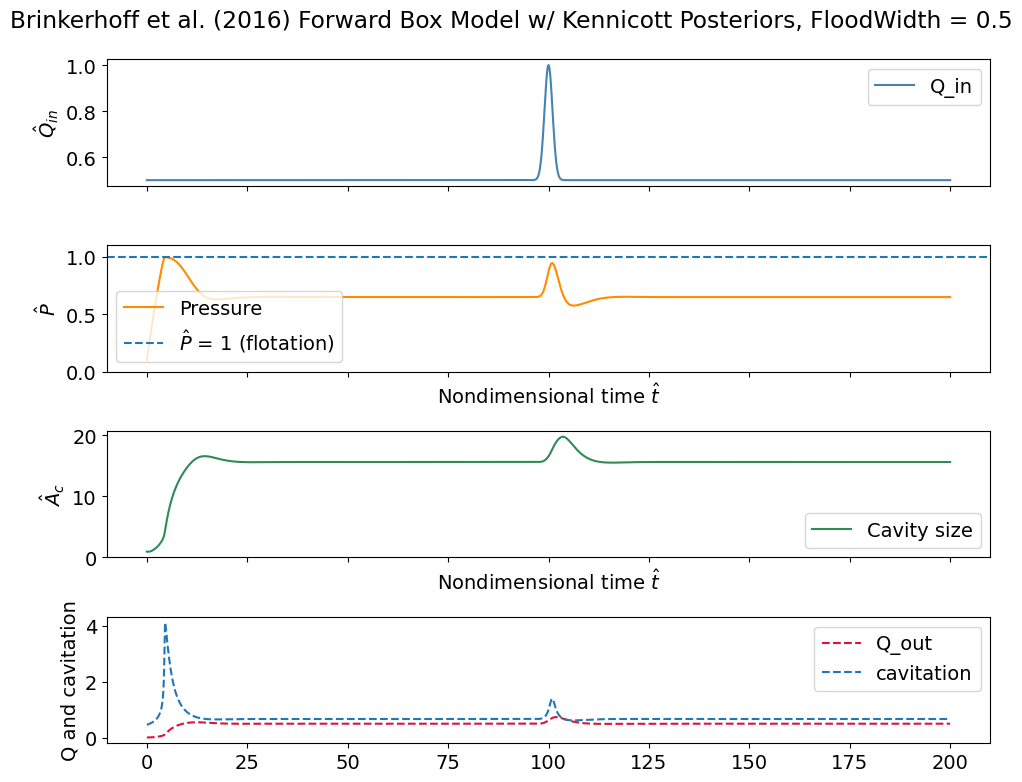

In [52]:
t = times
plt.rcParams.update({'font.size': 14})

Q_in_vals = np.array([Q_in_func(ti) for ti in t])

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, Q_in_vals, label="Q_in", color="steelblue")
axes[0].set_ylabel("$\\hat{Q}_{in}$")
axes[0].legend();

axes[1].plot(t, P_hat, label="Pressure", color="darkorange")
axes[1].set_ylabel("$\\hat{P}$")
axes[1].set_ylim(0, 1.1)
axes[1].set_xlabel("Nondimensional time $\\hat{t}$")
axes[1].axhline(1, label= "$\\hat{P}$ = 1 (flotation)", linestyle='--')
#axes[1].axvline(t_post, label = "$t_{post}$", color = "gray", linestyle="--")
#axes[1].text(0.05, 0.8, "pressure deficit = " + str(P_deficit), transform=axes[1].transAxes)# Places text in the top-left corner
axes[1].legend();

axes[2].plot(t, A_hat, label="Cavity size", color="seagreen")
axes[2].set_ylabel("$\\hat{A}_c$")
axes[2].set_xlabel("Nondimensional time $\\hat{t}$")
axes[2].legend(); 

axes[3].plot(t, Q_out, label="Q_out", color="crimson", linestyle="--")
axes[3].plot(t, cavitation, label = "cavitation", linestyle='--')
axes[3].set_ylabel("Q and cavitation")
axes[3].legend();

fig.suptitle("Brinkerhoff et al. (2016) Forward Box Model w/ Kennicott Posteriors, FloodWidth = 0.5")
plt.tight_layout()

## Get pressure drop for normal curve flood

In [227]:
# 1. Develop function that measures the characteristics of the pressure drop

def pressureDrop_properties(times, P_hat, t_flood, flood_width):

    '''
    Inputs:
    times, P_hat: outputs of solve() function
    t_flood, flood_width: inputs for make_synthetic_Q_in
    '''
    flood_width = int(flood_width)
    t_after = t_flood + 3*flood_width
    t_before = t_flood - 4*flood_width
    P_before = P_hat[t_before] # pressure 4 standard deviations before the flood occurs

    post_flood_period = int(50*len(times))

    P_after, t_after = min(P_hat[t_after:t_after + post_flood_period]), np.argmin(P_hat[t_after:t_after + post_flood_period])+t_after

    P_drop = (P_before - P_after)

    return P_drop, P_before, P_after, t_before, t_after

In [255]:
flood_width = 5
Q_in = make_synthetic_Q_in(t_flood, 5.0, flood_width, "norm") # assumes a flood magnitude of 5.0
times, A_hat, P_hat, Q_out, cavitation = solve(
    t_span=(t_start, t_end),
    t_eval = t_eval,
    Q_in_func=Q_in
    )

pdrop, pbefore, pafter, tbefore, tafter = pressureDrop_properties(times, P_hat, t_flood, 10)

0


In [259]:
plt.rcParams['figure.dpi'] = 200

Text(0, 0.5, '$\\hat{P}$')

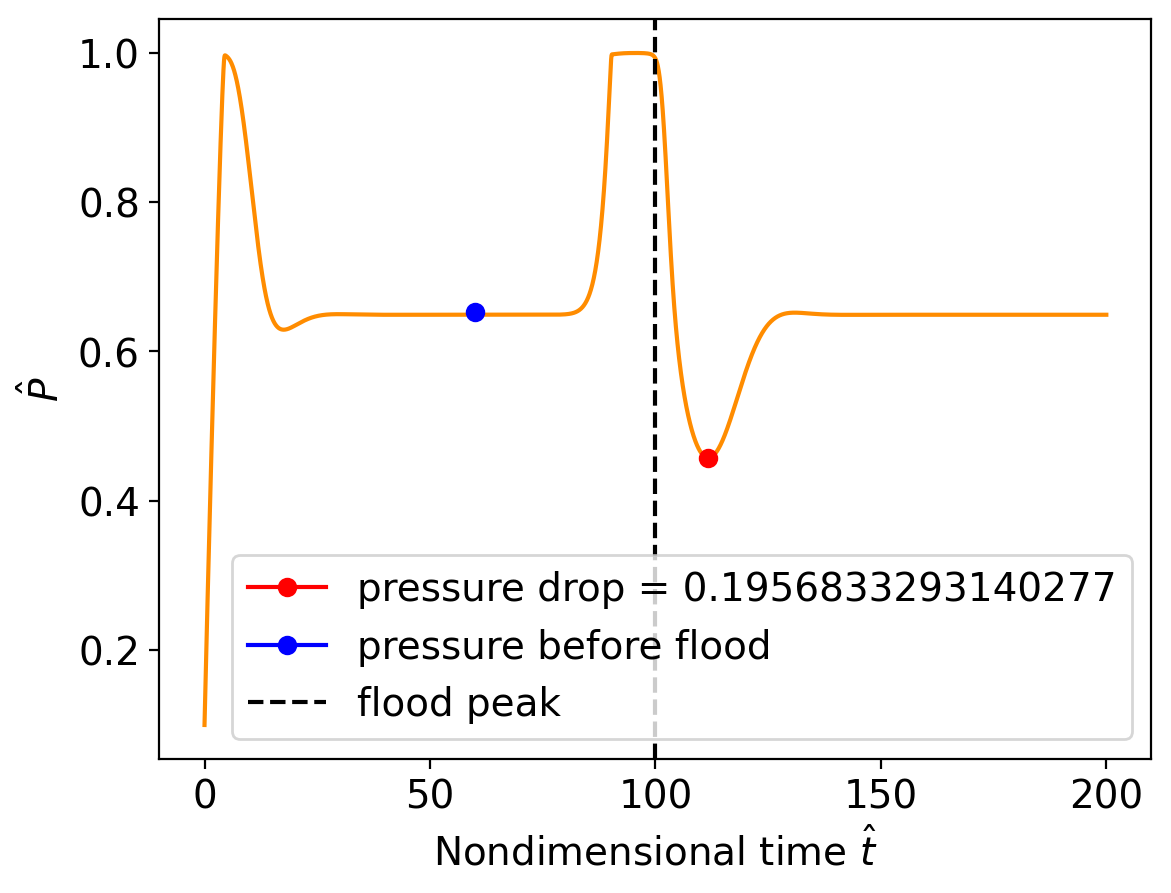

In [263]:
plt.plot(t, P_hat, color="darkorange")
plt.plot(times[tafter], pafter, marker='o', color='red', label="pressure drop = " + str(pdrop))
plt.plot(tbefore, pbefore, marker='o', color='blue', label="pressure before flood")
#plt.axvline(times[tafter], linestyle='--')
#plt.axvline(tbefore)
plt.axvline(t_flood, linestyle='--', color='black', label="flood peak")
plt.legend()
plt.xlabel("Nondimensional time $\\hat{t}$")
plt.ylabel("$\\hat{P}$")

In [236]:
# 2. Run the model for a bunch of different flood magnitudes

magnitudes = np.linspace(0.1, 11.0, 10)
p_drops = []
cavitation_drops = []
for m in magnitudes:

    Q_in = make_synthetic_Q_in(t_flood, m, flood_width, "norm")
    times, A_hat, P_hat, Q_out, cavitation = solve(
        t_span=(t_start, t_end),
        t_eval = t_eval,
        Q_in_func=Q_in
    )

    P_drop, P_before, P_after, t_before, t_after = pressureDrop_properties(times, P_hat, t_flood, flood_width)

    cavitation_drop = cavitation[t_flood-10]-cavitation[t_after]
    p_drops.append(P_drop)
    cavitation_drops.append(cavitation_drop)
    


0
0
0
0
0
0
0
0
0
0


Text(0.5, 1.0, 'Drop in pressure and sliding following flood')

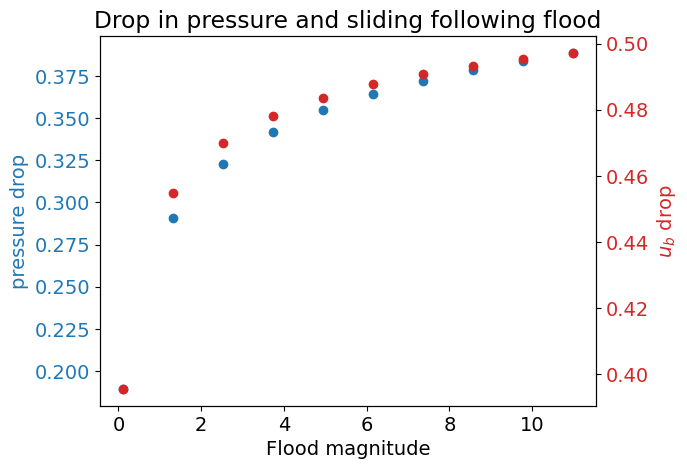

In [247]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.scatter(magnitudes, p_drops, marker='o', color=color)
ax1.set_ylabel("pressure drop", color=color)
ax1.tick_params(axis='y', labelcolor=color)

color2 = 'tab:red'
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
plt.scatter(magnitudes, cavitation_drops, marker = 'o', color=color2)
ax1.set_xlabel("Flood magnitude")
ax2.set_ylabel("$u_b$ drop", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Drop in pressure and sliding following flood")

In [251]:
# Now figure out the relationship with the flood width

# def make_synthetic_Q_in(t_flood, flood_magnitude, flood_width, floodtype)

widths = np.linspace(1.0, 20.0, 10)
p_drops = []
cavitation_drops = []
for w in widths:

    Q_in = make_synthetic_Q_in(t_flood, 5.0, w, "norm") # assumes a flood magnitude of 5.0
    times, A_hat, P_hat, Q_out, cavitation = solve(
        t_span=(t_start, t_end),
        t_eval = t_eval,
        Q_in_func=Q_in
    )

    P_drop, P_before, P_after, t_before, t_after = pressureDrop_properties(times, P_hat, t_flood, w)

    cavitation_drop = cavitation[t_flood-10]-cavitation[t_after]
    p_drops.append(P_drop)
    cavitation_drops.append(cavitation_drop)


/var/folders/c0/6r4n734n7fx5t4dn9q57_g480000gp/T/ipykernel_3606/389607685.py:14: RuntimeWarning: invalid value encountered in scalar power
  sliding_opening = k_hat/((1-P_hat)**gamma)


0
0
0
0
0
0
0
0
0
0


Text(0.5, 1.0, 'Drop in pressure and sliding following flood')

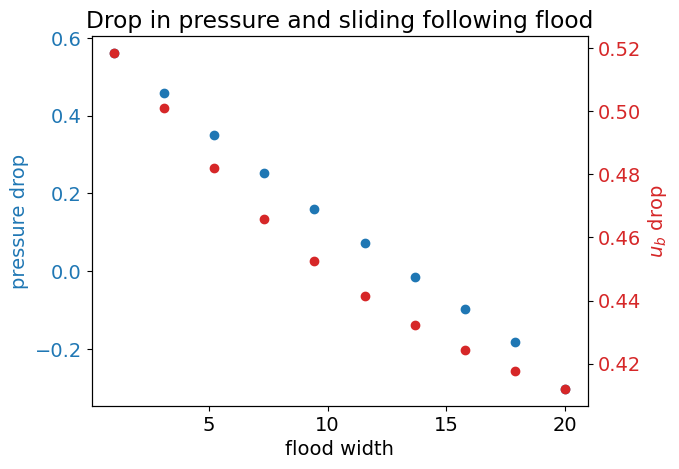

In [254]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.scatter(widths, p_drops, marker='o', color=color)
ax1.set_ylabel("pressure drop", color=color)
ax1.tick_params(axis='y', labelcolor=color)

color2 = 'tab:red'
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
plt.scatter(widths, cavitation_drops, marker = 'o', color=color2)
ax1.set_xlabel("flood width")
ax2.set_ylabel("$u_b$ drop", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Drop in pressure and sliding following flood")

## Get pressure drop for a long leadup flood

In [277]:
# 1. Develop function that measures the characteristics of the pressure drop

def pressureDrop_properties_longleadup(times, P_hat, t_flood, flood_width):

    '''
    Inputs:
    times, P_hat: outputs of solve() function
    t_flood, flood_width: inputs for make_synthetic_Q_in
    '''
    flood_width = int(flood_width)
    t_after = t_flood + 4*flood_width
    t_before = t_flood - 4*flood_width
    P_before = P_hat[t_before] # pressure 4 standard deviations before the flood occurs

    post_flood_period = int(50*len(times))

    P_after, t_after = min(P_hat[t_after:t_after + post_flood_period]), np.argmin(P_hat[t_after:t_after + post_flood_period])+t_after

    P_drop = (P_before - P_after)

    return P_drop, P_before, P_after, t_before, t_after

In [280]:
flood_width = 5
Q_in = make_synthetic_Q_in(t_flood, 5.0, flood_width, "long") # assumes a flood magnitude of 5.0
times, A_hat, P_hat, Q_out, cavitation = solve(
    t_span=(t_start, t_end),
    t_eval = t_eval,
    Q_in_func=Q_in
    )

pdrop, pbefore, pafter, tbefore, tafter = pressureDrop_properties(times, P_hat, t_flood, 10)

0


/var/folders/c0/6r4n734n7fx5t4dn9q57_g480000gp/T/ipykernel_3606/389607685.py:14: RuntimeWarning: invalid value encountered in scalar power
  sliding_opening = k_hat/((1-P_hat)**gamma)


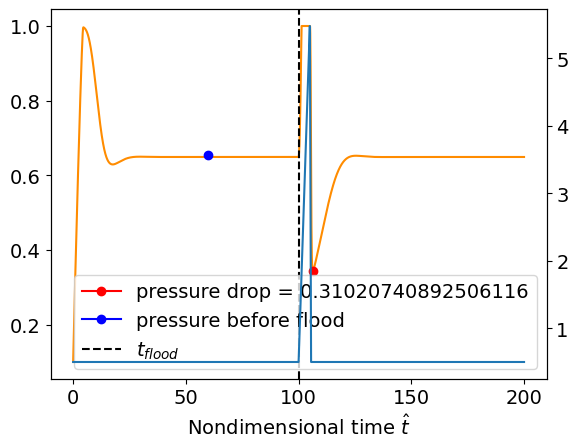

In [283]:
# Test to make sure the pressure drop function is working 
fig, ax1 = plt.subplots()

ax1.plot(t, P_hat, color="darkorange")
ax1.plot(times[tafter], pafter, marker='o', color='red', label="pressure drop = " + str(pdrop))
ax1.plot(tbefore, pbefore, marker='o', color='blue', label="pressure before flood")
#plt.axvline(times[tafter], linestyle='--')
#plt.axvline(tbefore)
ax1.axvline(t_flood, linestyle='--', color='black', label="$t_{flood}$")
ax1.set_xlabel("Nondimensional time $\\hat{t}$")
ax2.set_ylabel("$\\hat{P}$")

ax2 = ax1.twinx() 
ax2.plot(t, np.array([Q_in(ti) for ti in t]))
ax1.legend()

In [284]:
# 2. Run the model for a bunch of different flood magnitudes

magnitudes = np.linspace(0.1, 11.0, 10)
p_drops = []
cavitation_drops = []
for m in magnitudes:

    Q_in = make_synthetic_Q_in(t_flood, m, flood_width, "long")
    times, A_hat, P_hat, Q_out, cavitation = solve(
        t_span=(t_start, t_end),
        t_eval = t_eval,
        Q_in_func=Q_in
    )

    P_drop, P_before, P_after, t_before, t_after = pressureDrop_properties(times, P_hat, t_flood, flood_width)

    cavitation_drop = cavitation[t_flood-10]-cavitation[t_after]
    p_drops.append(P_drop)
    cavitation_drops.append(cavitation_drop)
    


0
0


/var/folders/c0/6r4n734n7fx5t4dn9q57_g480000gp/T/ipykernel_3606/389607685.py:14: RuntimeWarning: invalid value encountered in scalar power
  sliding_opening = k_hat/((1-P_hat)**gamma)


0
0
0
0
0
0
0
0


In [268]:
plt.rcParams['figure.dpi'] = 100

Text(0.5, 1.0, 'Drop in pressure and sliding following flood')

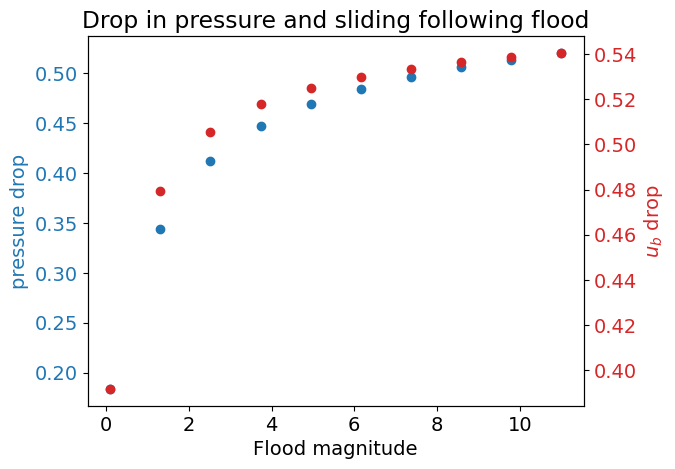

In [285]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.scatter(magnitudes, p_drops, marker='o', color=color)
ax1.set_ylabel("pressure drop", color=color)
ax1.tick_params(axis='y', labelcolor=color)

color2 = 'tab:red'
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
plt.scatter(magnitudes, cavitation_drops, marker = 'o', color=color2)
ax1.set_xlabel("Flood magnitude")
ax2.set_ylabel("$u_b$ drop", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Drop in pressure and sliding following flood")

In [286]:
# Now figure out the relationship with the flood width

# def make_synthetic_Q_in(t_flood, flood_magnitude, flood_width, floodtype)

widths = np.linspace(1.0, 20.0, 10)
p_drops = []
cavitation_drops = []
for w in widths:

    Q_in = make_synthetic_Q_in(t_flood, 5.0, w, "long") # assumes a flood magnitude of 5.0
    times, A_hat, P_hat, Q_out, cavitation = solve(
        t_span=(t_start, t_end),
        t_eval = t_eval,
        Q_in_func=Q_in
    )

    P_drop, P_before, P_after, t_before, t_after = pressureDrop_properties(times, P_hat, t_flood, w)

    cavitation_drop = cavitation[t_flood-10]-cavitation[t_after]
    p_drops.append(P_drop)
    cavitation_drops.append(cavitation_drop)


/var/folders/c0/6r4n734n7fx5t4dn9q57_g480000gp/T/ipykernel_3606/389607685.py:14: RuntimeWarning: invalid value encountered in scalar power
  sliding_opening = k_hat/((1-P_hat)**gamma)


0
0
0
0
0
0
0
0
0
0


Text(0.5, 1.0, 'Drop in pressure and sliding following flood')

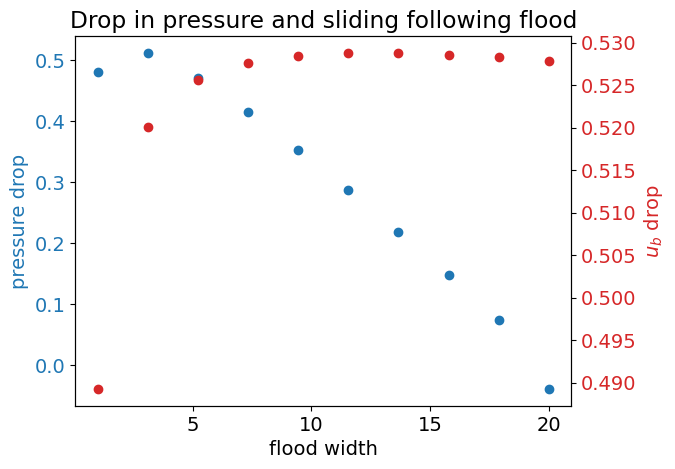

In [287]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.scatter(widths, p_drops, marker='o', color=color)
ax1.set_ylabel("pressure drop", color=color)
ax1.tick_params(axis='y', labelcolor=color)

color2 = 'tab:red'
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
plt.scatter(widths, cavitation_drops, marker = 'o', color=color2)
ax1.set_xlabel("flood width")
ax2.set_ylabel("$u_b$ drop", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Drop in pressure and sliding following flood")